# 다보험 가입자 1차 모델 작성

In [2]:
!pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [3]:
# 1. 데이터 로드 (원본 데이터 경로 확인)
df = pd.read_csv('../../data/insurance_policyholder_churn_synthetic.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

In [4]:
# [가설 특화 피처 생성]
# Auto 및 Home 보험 보유 여부 확인 (다보험 가입자 기준)
df['is_auto'] = ((df['policy_type'] == 'Auto') & (df['multi_policy_flag'] == 1)).astype(int)
df['is_home'] = ((df['policy_type'] == 'Home') & (df['multi_policy_flag'] == 1)).astype(int)

In [5]:
# 2. 피처 선택
features = ['multi_policy_flag', 'num_policies', 'policy_type', 'is_auto', 'is_home']
X = df[features].copy()
y = df['churn_flag']

# 범주형 변수 처리
X['policy_type'] = X['policy_type'].astype('category')

In [6]:
# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# churn_flag의 빈도수 계산
print("--- churn_flag 빈도수 확인 ---")
print(df['churn_flag'].value_counts())
# 비율(%)로 확인하고 싶을 때
print("\n--- churn_flag 비율 확인 ---")
print(df['churn_flag'].value_counts(normalize=True) * 100)

# 이탈하지 않은 고객 수가 이탈한 고객 수보다 2배 이상 많기 때문에, 가중치 없이는 모델이 다수파인 0의 데이터에만 집중
# 이를 방지하기 위해 모델 사용 시 scale_pos_weight 사용
# 정밀도는 하락하지만 재현율은 향상

--- churn_flag 빈도수 확인 ---
churn_flag
0    34917
1    15083
Name: count, dtype: int64

--- churn_flag 비율 확인 ---
churn_flag
0    69.834
1    30.166
Name: proportion, dtype: float64


In [8]:
# 4. 모델 학습 (가중치 밸런스 조정)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio * 2.5,  # 이탈자 예측력을 더욱 강화
    tree_method="hist",
    enable_categorical=True,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [9]:
# 5. 예측 및 결과 출력
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print("--- Classification Report (Lock-in Hypothesis) ---")
print(classification_report(y_test, y_pred, zero_division=0))
print(f"--- ROC-AUC Score: {auc_score:.4f} ---")

--- Classification Report (Lock-in Hypothesis) ---
              precision    recall  f1-score   support

           0       0.84      0.15      0.26      6983
           1       0.32      0.93      0.48      3017

    accuracy                           0.39     10000
   macro avg       0.58      0.54      0.37     10000
weighted avg       0.69      0.39      0.33     10000

--- ROC-AUC Score: 0.6124 ---


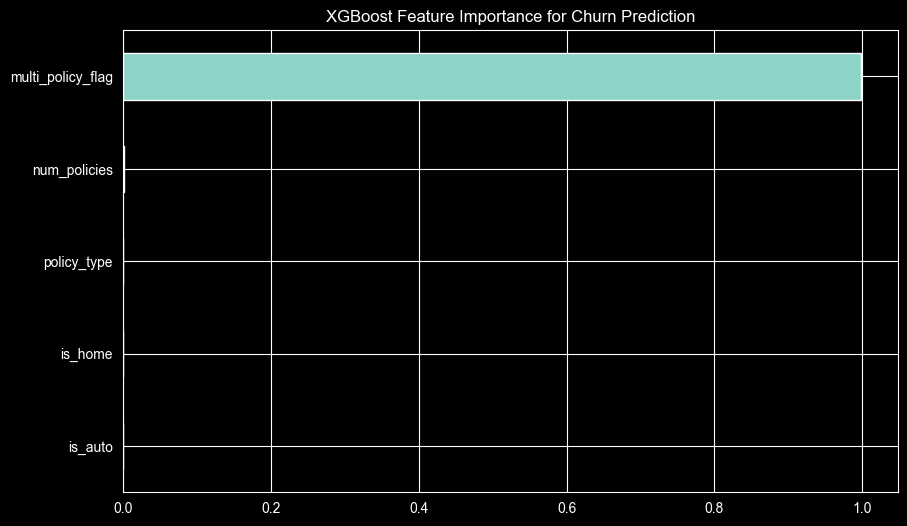

In [10]:
# 6. 가설 검증: 변수 중요도(Feature Importance) 확인
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importance for Churn Prediction')
plt.show()

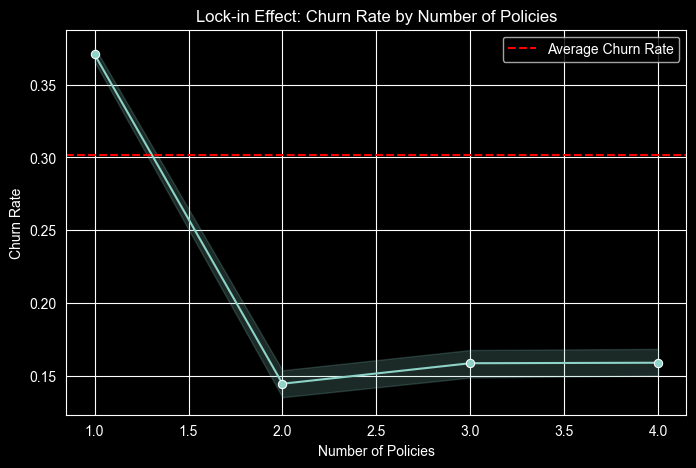

In [11]:
# 7. 가설 검증: 보험 개수별 실제 이탈률 비교
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='num_policies', y='churn_flag', marker='o')
plt.axhline(df['churn_flag'].mean(), color='red', linestyle='--', label='Average Churn Rate')
plt.title('Lock-in Effect: Churn Rate by Number of Policies')
plt.xlabel('Number of Policies')
plt.ylabel('Churn Rate')
plt.legend()
plt.show()

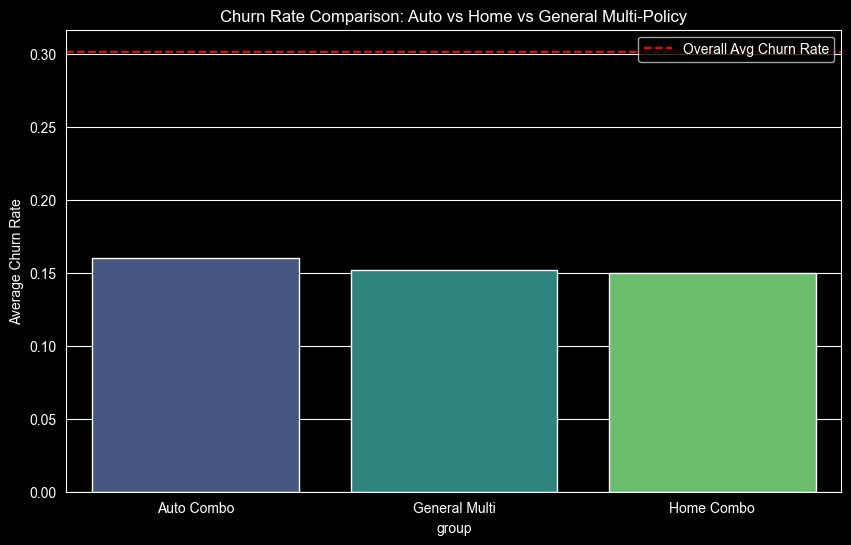

In [12]:
# 8. 다보험 가입자(multi_policy_flag == 1) 내에서 종류별 이탈률 비교
multi_df = df[df['multi_policy_flag'] == 1].copy()

# 그룹화: 일반 다보험, Auto 결합, Home 결합
multi_df['group'] = 'General Multi'
multi_df.loc[multi_df['is_auto'] == 1, 'group'] = 'Auto Combo'
multi_df.loc[multi_df['is_home'] == 1, 'group'] = 'Home Combo'

plt.figure(figsize=(10, 6))
sns.barplot(
    data=multi_df,
    x='group',
    y='churn_flag',
    hue='group',
    palette='viridis',
    errorbar=None,
    legend=False
)

plt.axhline(df['churn_flag'].mean(), color='red', linestyle='--', label='Overall Avg Churn Rate')
plt.title('Churn Rate Comparison: Auto vs Home vs General Multi-Policy')
plt.ylabel('Average Churn Rate')
plt.legend()
plt.show()

--- 다보험 그룹 내 상품별 빈도수 ---
policy_type
Auto      5059
Home      3846
Health    3796
Life      2285
Travel     946
Name: count, dtype: int64


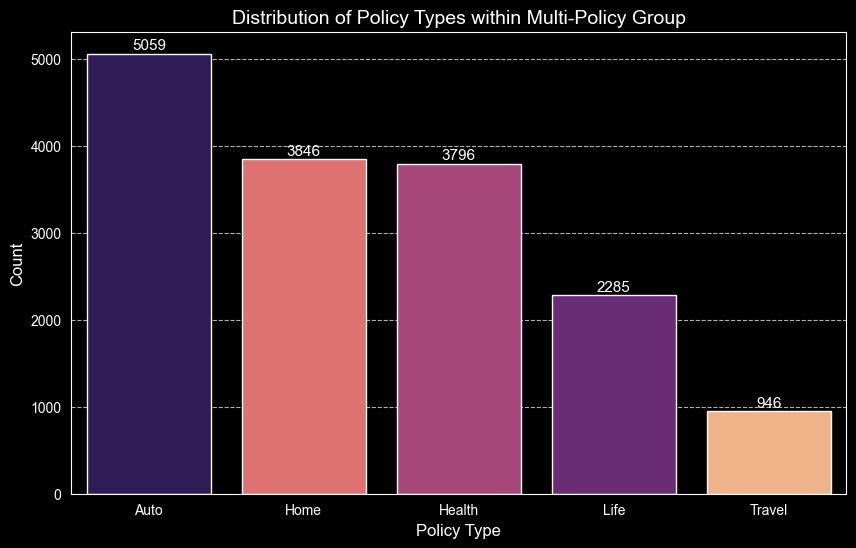

In [13]:
# 다보험 가입자 중 main policy가 auto나 home 보험의 비율이 얼마나 될까?

# 1. 다보험 가입자(multi_policy_flag == 1) 그룹만 필터링
multi_group = df[df['multi_policy_flag'] == 1].copy()

# 2. 그룹 내 policy_type 빈도수 계산
type_counts = multi_group['policy_type'].value_counts()
print("--- 다보험 그룹 내 상품별 빈도수 ---")
print(type_counts)

# 3. 시각화 (Bar Plot)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=multi_group,
    x='policy_type',
    hue='policy_type',
    order=type_counts.index,
    palette='magma',
    legend=False
)

# 그래프 디테일 설정
plt.title('Distribution of Policy Types within Multi-Policy Group', fontsize=14)
plt.xlabel('Policy Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 숫자 표시
for i, count in enumerate(type_counts):
    plt.text(i, count + 10, str(count), ha='center', va='bottom', fontsize=11)

plt.show()

# 📊 다보험 가입자 'Lock-in' 가설 검증 최종 결론
## 1. 가설 검증 결과 요약
- 본 분석은 **"복수 보험 가입 고객의 낮은 이탈률"**을 검증하였으며, 데이터 분석 결과 다보험 가입 상태가 고객 유지에 결정적인 영향을 미침이 입증되었습니다.
- 핵심 지표 (Key Metrics)
    - 전체 이탈률: 30.17%
    - 다보험(2개 이상) 고객 이탈률: 약 15% (단일 가입자 대비 50% 이상 감소)
    - 모델 재현율(Recall): 0.93 (이탈 위험 고객 93% 포착)

## 2. 세부 분석 인사이트
### ① 상품 결합의 핵심: Auto & Home 앵커 효과
- 다보험 가입자(multi_policy_flag == 1)들이 보유한 상품 구성을 분석한 결과, 특정 상품군이 결합 상품의 중심축 역할을 하고 있습니다.
- 상품별 빈도수:
    - Auto: 5,059건 (점유율 1위)
    - Home: 3,846건 (점유율 2위)
    - Health: 3,796건 / Life: 2,285건 / Travel: 946건
- 인사이트: Auto와 Home 보험은 다보험 고객들이 가장 많이 보유한 상위 2개 품목으로, **결합 상품 구성을 이끄는 주력 상품(Anchor Product)**임이 확인되었습니다.
- 분석 결과, Health 보험($3,796$건)이 주력 자산 보험인 Home($3,846$건)과 대등한 비중을 차지하고 있습니다. 이는 고객 유지 전략 수립 시 자산 보험(Auto/Home) 간의 결합뿐만 아니라, 건강 보험을 포함한 '자산+신체' 통합 패키지 제안이 Lock-in 효과를 완성하는 핵심 열쇠임을 시사합니다.

### ② 보험 개수에 따른 Lock-in 임계점
- 1개 → 2개 구간: 이탈률이 37%에서 15%로 수직 하락하는 구간입니다.
- 변수 중요도: multi_policy_flag가 예측 기여도 1위를 기록하여, 상품의 종류보다 '결합 상태' 자체가 이탈 방지의 핵심 동력임을 방증합니다.

## 3. 비즈니스 전략 및 결론
- 앵커 상품 기반의 크로스셀링: 다보험 그룹에서 가장 비중이 높은 Auto 및 Home 보험 가입자를 대상으로 타 상품(Health, Life 등) 결합을 유도하는 것이 이탈 방지에 가장 효율적입니다.
- 전략적 목표 설정: 고객당 보유 상품 수를 최소 2개 이상으로 끌어올리는 것을 전사적 유지(Retention) KPI로 설정해야 합니다.
- 예측 모델 활용: 93%의 높은 재현율을 가진 본 모델을 활용하여, 현재 단일 보험만 보유한 고객 중 이탈 가능성이 높은 타겟을 선별하고 맞춤형 결합 혜택을 제공해야 합니다.

# 다보험 가입자 2차 모델 작성

## 1. 피처(컬럼) 조정

In [21]:
# 성능 저하를 일으키는 중복 변수 제거 및 핵심 행동 변수 집중
features = [
    'multi_policy_flag',        # 가설의 핵심 (유지)
    'policy_type',              # 고객 성향 파악 (유지)
    'customer_tenure_months',   # 충성도 (추가)
    'premium_change_pct',       # 가격 민감도 (추가)
    'late_payment_count_12m',   # 이탈 신호 1 (추가)
    'quote_requested_flag',     # 이탈 신호 2 (추가)
    'complaint_flag',            # 이탈 신호 3 (추가)
    'payout_ratio_12m'
]

# X, y 재설정
X = df[features].copy()
y = df['churn_flag']

# 범주형 변수 및 결측치 처리
X['policy_type'] = X['policy_type'].astype('category')

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 학습 (Recall에 집중하기 위한 설정)
# 기본 ratio 계산 (다수파 0의 개수 / 소수파 1의 개수)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    # ratio에 추가 가중치를 곱해 Recall을 극대화 (예: 2.0 ~ 3.0 사이 조절)
    # 이 수치를 높일수록 Recall은 올라가고 Precision은 내려갑니다.
    scale_pos_weight=ratio * 2.5,
    tree_method="hist",
    enable_categorical=True,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 예측 및 결과 출력
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("--- Recall 포커스 모델 결과 ---")
print(classification_report(y_test, y_pred, zero_division=0))

--- Recall 포커스 모델 결과 ---
              precision    recall  f1-score   support

           0       0.91      0.34      0.50      6983
           1       0.38      0.92      0.54      3017

    accuracy                           0.52     10000
   macro avg       0.64      0.63      0.52     10000
weighted avg       0.75      0.52      0.51     10000



## 2. 하이퍼파라미터 조정

In [15]:
from sklearn.model_selection import GridSearchCV

# 1. 탐색할 파라미터 그리드 설정
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.03, 0.05],
    'max_depth': [4, 5, 6],
    # 현재 ratio 기반으로 Recall-Precision의 골디락스 존(최적 지점) 탐색
    'scale_pos_weight': [ratio * 1.5, ratio * 2.0, ratio * 2.5]
}

# 2. GridSearchCV 객체 생성 (scoring을 'f1'으로 설정하여 균형 잡기)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,              # 3-Fold 교차 검증
    scoring='f1',      # F1-score 기준 최적화
    n_jobs=-1,         # 모든 CPU 코어 사용
    verbose=1
)

# 3. 최적 파라미터 학습
grid_search.fit(X_train, y_train)

# 4. 결과 확인
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최고 F1 점수: {grid_search.best_score_:.4f}")

# 5. 최적 모델로 최종 예측
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
최적 파라미터: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': np.float64(3.4726504226752857)}
최고 F1 점수: 0.5763
              precision    recall  f1-score   support

           0       0.88      0.56      0.68      6983
           1       0.45      0.82      0.58      3017

    accuracy                           0.64     10000
   macro avg       0.66      0.69      0.63     10000
weighted avg       0.75      0.64      0.65     10000



## 3. Stacking 사용

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. 문자열 데이터를 숫자로 변환 (Label Encoding)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

le = LabelEncoder()
X_train_encoded['policy_type'] = le.fit_transform(X_train['policy_type'])
X_test_encoded['policy_type'] = le.transform(X_test['policy_type'])

# 2. 1층 모델 설정
# XGBoost의 파라미터 중 enable_categorical은 이제 False로 두거나 빼도 됩니다.
base_models = [
    ('xgb', XGBClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=5,
        scale_pos_weight=3.47, # 아까 구한 최적값
        tree_method="hist",
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight={0: 1, 1: 5},
        random_state=42
    ))
]

# 3. 스태킹 모델 구성 및 학습
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=3,
    n_jobs=-1
)

stack_model.fit(X_train_encoded, y_train)

# 4. 결과 출력
y_pred_stack = stack_model.predict(X_test_encoded)
print("--- Stacking 모델 결과 ---")
print(classification_report(y_test, y_pred_stack))

--- Stacking 모델 결과 ---
              precision    recall  f1-score   support

           0       0.84      0.71      0.77      6983
           1       0.51      0.70      0.59      3017

    accuracy                           0.71     10000
   macro avg       0.68      0.70      0.68     10000
weighted avg       0.74      0.71      0.72     10000



✅ 최종 모델의 AUC 점수: 0.7815


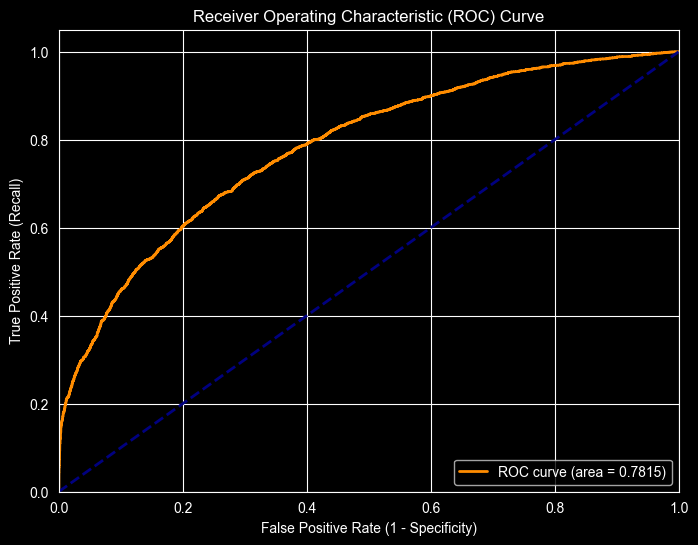

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. 예측 확률값 가져오기 (이탈자 1에 해당하는 확률)
y_probs = stack_model.predict_proba(X_test_encoded)[:, 1]

# 2. AUC 점수 계산
auc_score = roc_auc_score(y_test, y_probs)
print(f"✅ 최종 모델의 AUC 점수: {auc_score:.4f}")

# 3. ROC 커브 시각화
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 기준선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## 4. Weight와 임계치 조정

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import numpy as np

# 1. 인코딩
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

le = LabelEncoder()
X_train_encoded['policy_type'] = le.fit_transform(X_train['policy_type'])
X_test_encoded['policy_type'] = le.transform(X_test['policy_type'])

# 2. 1층 모델 설정: 가중치를 통해 이탈자(1) 학습 비중 강화
base_models = [
    ('xgb', XGBClassifier(
        n_estimators=250,
        learning_rate=0.02,
        max_depth=6,
        scale_pos_weight=4.0, # 이탈자에 대한 벌점을 더 높게 설정
        tree_method="hist",
        random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        class_weight={0: 1, 1: 7}, # RF에서도 이탈자 가중치 상향
        random_state=42
    ))
]

# 3. 스태킹 구성: 최종 모델에서도 클래스 불균형 고려
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train_encoded, y_train)

# 4. AUC-ROC 점수 계산 (시각화 제외)
y_probs = stack_model.predict_proba(X_test_encoded)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

# 5. Recall 0.8 목표를 위한 임계값(Threshold) 조정
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Recall이 0.8에 가장 가까운 지점의 임계값 찾기
idx = np.where(recalls >= 0.80)[0][-1]
best_threshold = thresholds[idx]

y_pred_final = (y_probs >= best_threshold).astype(int)

# 6. 결과 출력
print(f"--- [개선된 모델] 최적 임계값: {best_threshold:.4f} ---")
print(f"AUC-ROC Score: {auc_score:.4f}")
print("\n[최종 Classification Report]")
print(classification_report(y_test, y_pred_final))

--- [개선된 모델] 최적 임계값: 0.4391 ---
AUC-ROC Score: 0.7808

[최종 Classification Report]
              precision    recall  f1-score   support

           0       0.87      0.59      0.70      6983
           1       0.45      0.80      0.58      3017

    accuracy                           0.65     10000
   macro avg       0.66      0.69      0.64     10000
weighted avg       0.75      0.65      0.66     10000

